<a href="https://colab.research.google.com/github/IT24102850/srilanka-flood-warning/blob/main/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# ── Load rainfall ──────────────────────────────────────────
rainfall = pd.read_csv("data/processed/gpm_monthly_srilanka.csv")

# ── Load DesInventar ───────────────────────────────────────
# Upload your LKA.dbf file first, then:
from dbfread import DBF
table = DBF("LKA.dbf", encoding="latin-1")
raw = pd.DataFrame(iter(table))

# Inspect columns — paste the output here
print(raw.columns.tolist())
print(raw.head(3))

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/gpm_monthly_srilanka.csv'

In [2]:
# Step 1 — mount Google Drive (do this ONCE, files persist forever)
from google.colab import drive
drive.mount('/content/drive')

# Step 2 — create project folder in your Drive
import os
os.makedirs("/content/drive/MyDrive/srilanka_flood/data/processed", exist_ok=True)
os.makedirs("/content/drive/MyDrive/srilanka_flood/data/raw/gpm", exist_ok=True)

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Cell 1 — mount Drive and imports
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import pandas as pd
import glob
import os

os.makedirs("/content/drive/MyDrive/srilanka_flood/data/processed", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Cell 1 — mount Drive + install + login
from google.colab import drive
drive.mount('/content/drive')

!pip install earthaccess xarray netCDF4 h5py -q

import earthaccess, xarray as xr, pandas as pd, glob, os

os.makedirs("/content/drive/MyDrive/srilanka_flood/data/raw/gpm", exist_ok=True)
os.makedirs("/content/drive/MyDrive/srilanka_flood/data/processed", exist_ok=True)

earthaccess.login(strategy="interactive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 72.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
Enter your Earthdat

In [8]:
BBOX = (79.5, 5.9, 81.9, 9.8)
results = earthaccess.search_data(
    short_name="GPM_3IMERGM",
    version="07",
    temporal=("2000-06-01", "2023-12-31"),
    bounding_box=BBOX
)
print(f"Found {len(results)} files")

Found 283 files


/usr/local/lib/python3.12/dist-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [9]:
files = earthaccess.download(
    results,
    "/content/drive/MyDrive/srilanka_flood/data/raw/gpm"
)
print(f"Downloaded {len(files)} files to Drive")

/usr/local/lib/python3.12/dist-packages/earthaccess/store.py:838: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum(granule.size() for granule in granules) / 1024, 2)


QUEUEING TASKS | :   0%|          | 0/283 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/283 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/283 [00:00<?, ?it/s]

Downloaded 283 files to Drive


In [10]:
!pip install dbfread -q
from dbfread import DBF
import pandas as pd

# Load disaster events
dsdivi = DBF(
    "/content/drive/MyDrive/srilanka_flood/data/raw/dsdivi.dbf",
    encoding="latin-1"
)
df = pd.DataFrame(iter(dsdivi))

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))
print("\nDisaster types:")
print(df['FENOMENO'].value_counts().head(20))

Shape: (328, 8)

Columns: ['PROVINCE_N', 'DISTRICT_N', 'DSD_N', 'DSDCODE4', 'pro_code', 'dis_code', 'ds_code', 'Agecies']

First 3 rows:
  PROVINCE_N DISTRICT_N                        DSD_N DSDCODE4 pro_code  \
0    Eastern     Ampara               Addalachchenai     5233   lka005   
1    Eastern     Ampara  Akkaraipattu(Karunkoditivu)     5236   lka005   
2    Eastern     Ampara                 Alayadiwembu     5239   lka005   

     dis_code       ds_code  Agecies  
0   lka005002  lka005002033        0  
1   lka005002  lka005002036        0  
2   lka005002  lka005002039        0  

Disaster types:


KeyError: 'FENOMENO'

In [11]:
import xml.etree.ElementTree as ET
import pandas as pd

# Parse the XML export
tree = ET.parse("/content/drive/MyDrive/srilanka_flood/data/raw/DI_export_lka.xml")
root = tree.getroot()

records = []
for event in root.iter('fichas'):
    rec = {}
    for child in event:
        rec[child.tag] = child.text
    records.append(rec)

df_raw = pd.DataFrame(records)
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nFirst 3 rows:")
print(df_raw.head(3))

Shape: (1, 1)

Columns: ['TR']

First 3 rows:
     TR
0  None


In [12]:
# Explore the XML structure first
tree = ET.parse("/content/drive/MyDrive/srilanka_flood/data/raw/DI_export_lka.xml")
root = tree.getroot()

# Print the structure of first few elements
def explore(element, depth=0):
    if depth > 3:
        return
    print("  " * depth + f"<{element.tag}> : '{element.text[:30] if element.text and element.text.strip() else ''}'")
    for child in list(element)[:3]:
        explore(child, depth+1)

explore(root)

<DESINVENTAR> : ''
  <datamodel> : ''
    <TR> : ''
      <revision> : '16'
      <build> : '0'
      <slanguage> : ''
  <eventos> : ''
    <TR> : ''
      <serial> : '37'
      <nombre> : 'ACCIDENT'
      <nombre_en> : 'ACCIDENT'
    <TR> : ''
      <serial> : '7'
      <nombre> : 'ANIMAL ATTACK'
      <nombre_en> : 'ANIMAL ATTACK'
    <TR> : ''
      <serial> : '46'
      <nombre> : 'BOAT CAPSIZE'
      <nombre_en> : 'BOAT CAPSIZE'
  <causas> : ''
    <TR> : ''
      <causa> : 'Acute FP'
      <causa_en> : 'Acute FP'
    <TR> : ''
      <causa> : 'AIDS'
      <causa_en> : 'AIDS'
    <TR> : ''
      <causa> : 'Chicken pox'
      <causa_en> : 'Chicken pox'


In [13]:
records = []

# Find the fichas section specifically
fichas = root.find('fichas')

for tr in fichas.iter('TR'):
    rec = {}
    for child in tr:
        rec[child.tag] = child.text
    records.append(rec)

df_raw = pd.DataFrame(records)
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
print("\nFirst 3 rows:")
print(df_raw.head(3))
print("\nUnique FENOMENO values:")
print(df_raw['fenomeno'].value_counts().head(20))

Shape: (130140, 64)

Columns: ['serial', 'level0', 'level1', 'level2', 'name0', 'name1', 'name2', 'evento', 'lugar', 'fechano', 'fechames', 'fechadia', 'muertos', 'heridos', 'desaparece', 'afectados', 'vivdest', 'vivafec', 'otros', 'fuentes', 'valorloc', 'valorus', 'fechapor', 'fechafec', 'hay_muertos', 'hay_heridos', 'hay_deasparece', 'hay_afectados', 'hay_vivdest', 'hay_vivafec', 'hay_otros', 'socorro', 'salud', 'educacion', 'agropecuario', 'industrias', 'acueducto', 'alcantarillado', 'energia', 'comunicaciones', 'causa', 'descausa', 'transporte', 'magnitud2', 'nhospitales', 'nescuelas', 'nhectareas', 'cabezas', 'kmvias', 'duracion', 'damnificados', 'evacuados', 'hay_damnificados', 'hay_evacuados', 'hay_reubicados', 'reubicados', 'clave', 'glide', 'defaultab', 'approved', 'latitude', 'longitude', 'uu_id', 'di_comments']

First 3 rows:
   serial  level0     level1 level2          name0        name1 name2  \
0  EP2004  lka005  lka005001   None        Eastern   Batticaloa  None   
1  EP

KeyError: 'fenomeno'

In [14]:
print(df_raw['evento'].value_counts().head(20))

evento
EPIDEMIC           88411
ANIMAL ATTACK      10905
FLOOD               8220
STRONG WIND         6033
FIRE                3834
DROUGHT             3070
HEAVY RAINS         2728
LANDSLIDE           2256
LIGHTNING            896
GALE                 550
CUTTING FAILURE      525
PLAGUE               423
ACCIDENT             387
FOREST FIRE          241
Drowning             201
LAND SUBSIDENCE      187
Tree fallen          182
SNAKE BITE           125
CYCLONE              123
ROCK FALL            121
Name: count, dtype: int64


In [15]:
# Save full dataset to Drive
df_raw.to_csv(
    "/content/drive/MyDrive/srilanka_flood/data/raw/desinventar_lka.csv",
    index=False
)

# Filter to floods and landslides only
flood_events = df_raw[df_raw['evento'].str.upper().isin([
    'FLOOD', 'FLASH FLOOD', 'LANDSLIDE', 'MUDSLIDE',
    'DEBRIS FLOW', 'TORRENTIAL RAIN'
])].copy()

# Keep only columns we need
flood_events = flood_events[[
    'name1',      # district name
    'evento',     # disaster type
    'fechano',    # year
    'fechames',   # month
    'muertos',    # deaths
    'damnificados', # people affected
    'nhectareas'  # hectares damaged
]].copy()

flood_events['fechano'] = pd.to_numeric(flood_events['fechano'], errors='coerce')
flood_events['fechames'] = pd.to_numeric(flood_events['fechames'], errors='coerce')

flood_events = flood_events.dropna(subset=['fechano','fechames','name1'])

print("Flood/landslide events shape:", flood_events.shape)
print("\nEvent types:")
print(flood_events['evento'].value_counts())
print("\nTop districts:")
print(flood_events['name1'].value_counts().head(10))
print("\nYear range:", flood_events['fechano'].min(), "→", flood_events['fechano'].max())

Flood/landslide events shape: (10555, 7)

Event types:
evento
FLOOD          8219
LANDSLIDE      2256
FLASH FLOOD      80
Name: count, dtype: int64

Top districts:
name1
Ratnapura     1263
Kandy          970
Gampaha        786
Kalutara       633
Jaffna         601
Matara         584
Batticaloa     560
Kurunegala     544
Badulla        514
Colombo        452
Name: count, dtype: int64

Year range: 1974 → 2020


 build the feature table and train the model

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

# ── Load both datasets ─────────────────────────────────────
rainfall = pd.read_csv(
    "/content/drive/MyDrive/srilanka_flood/data/processed/gpm_monthly_srilanka.csv"
)

# ── Build district-month grid (2000-2020, overlap period) ──
districts = flood_events['name1'].unique().tolist()
years     = list(range(2000, 2021))
months    = list(range(1, 13))

grid = pd.MultiIndex.from_product(
    [districts, years, months],
    names=['district','year','month']
).to_frame(index=False)

# ── Add target variable ────────────────────────────────────
# 1 = at least one flood/landslide event in that district-month
events_agg = flood_events.groupby(
    ['name1','fechano','fechames']
).size().reset_index(name='event_count')

events_agg.columns = ['district','year','month','event_count']
events_agg['disaster'] = 1

grid = grid.merge(events_agg[['district','year','month','disaster']],
                  on=['district','year','month'], how='left')
grid['disaster'] = grid['disaster'].fillna(0).astype(int)

# ── Add rainfall features ──────────────────────────────────
grid = grid.merge(rainfall, on=['year','month'], how='left')

# Lag features — previous month and 3-month sum
grid = grid.sort_values(['district','year','month']).reset_index(drop=True)
grid['rainfall_prev1'] = grid.groupby('district')['rainfall_mm'].shift(1)
grid['rainfall_prev2'] = grid.groupby('district')['rainfall_mm'].shift(2)
grid['rainfall_3mo']   = grid['rainfall_prev1'] + grid['rainfall_prev2'] + grid['rainfall_mm']

# Month as cyclical feature (captures monsoon seasonality)
grid['month_sin'] = np.sin(2 * np.pi * grid['month'] / 12)
grid['month_cos'] = np.cos(2 * np.pi * grid['month'] / 12)

# ── Add static terrain features per district ───────────────
# Approximate elevation/slope risk scores based on geography
terrain = {
    'Ratnapura':1.0, 'Kandy':0.95, 'Badulla':0.95, 'Kegalle':0.90,
    'Nuwara Eliya':0.90, 'Matale':0.80, 'Kalutara':0.75, 'Galle':0.70,
    'Matara':0.70, 'Kurunegala':0.60, 'Colombo':0.55, 'Gampaha':0.55,
    'Hambantota':0.45, 'Trincomalee':0.50, 'Batticaloa':0.50,
    'Ampara':0.55, 'Polonnaruwa':0.40, 'Anuradhapura':0.40,
    'Puttalam':0.45, 'Mannar':0.35, 'Vavuniya':0.40, 'Mullaitivu':0.45,
    'Kilinochchi':0.35, 'Jaffna':0.30, 'Monaragala':0.65
}
grid['terrain_risk'] = grid['district'].map(terrain).fillna(0.5)

# ── Drop rows with NaN (first 2 months per district) ───────
grid = grid.dropna(subset=['rainfall_mm','rainfall_prev1','rainfall_3mo'])

print("Feature table shape:", grid.shape)
print("Disaster rate:", grid['disaster'].mean().round(4))
print("\nSample rows:")
print(grid[['district','year','month','rainfall_mm','rainfall_3mo','terrain_risk','disaster']].head(8))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/srilanka_flood/data/processed/gpm_monthly_srilanka.csv'

In [17]:
import glob, os

# Check if HDF5 files have downloaded to Drive yet
files = glob.glob("/content/drive/MyDrive/srilanka_flood/data/raw/gpm/*.HDF5")
print(f"HDF5 files in Drive: {len(files)}")

# Check if CSV already exists
csv_exists = os.path.exists(
    "/content/drive/MyDrive/srilanka_flood/data/processed/gpm_monthly_srilanka.csv"
)
print(f"CSV exists: {csv_exists}")

HDF5 files in Drive: 283
CSV exists: False


In [19]:
import xarray as xr, glob, os, pandas as pd, re

records = []
flist = sorted(glob.glob(
    "/content/drive/MyDrive/srilanka_flood/data/raw/gpm/*.HDF5"))

print(f"Parsing {len(flist)} files...")

for i, fpath in enumerate(flist):
    try:
        # Extract year and month from filename directly
        # e.g. 3B-MO.MS.MRG.3IMERG.20000601-S... → 2000, 06
        fname = os.path.basename(fpath)
        date_match = re.search(r'\.(\d{4})(\d{2})\d{2}-', fname)
        year  = int(date_match.group(1))
        month = int(date_match.group(2))

        ds = xr.open_dataset(fpath, group="Grid", engine="netcdf4")

        # Clip to Sri Lanka
        rain = ds['precipitation'].sel(
            lon=slice(79.5, 81.9),
            lat=slice(5.9, 9.8)
        )

        # mm/hr → mm/month
        import calendar
        hours_in_month = calendar.monthrange(year, month)[1] * 24
        monthly_mean_mm = float(rain.mean().values) * hours_in_month

        records.append({
            "year": year,
            "month": month,
            "rainfall_mm": round(monthly_mean_mm, 2)
        })
        ds.close()

    except Exception as e:
        print(f"Skipped {os.path.basename(fpath)}: {e}")

    if (i+1) % 50 == 0:
        print(f"  Parsed {i+1}/283...")

rainfall_df = pd.DataFrame(records).sort_values(
    ["year","month"]).reset_index(drop=True)

os.makedirs(
    "/content/drive/MyDrive/srilanka_flood/data/processed", exist_ok=True)
rainfall_df.to_csv(
    "/content/drive/MyDrive/srilanka_flood/data/processed/gpm_monthly_srilanka.csv",
    index=False)

print(f"\nDone! Saved {len(rainfall_df)} rows")
print(rainfall_df.head(6))
print("\nAverage by month:")
print(rainfall_df.groupby("month")["rainfall_mm"].mean().round(1))

Parsing 283 files...
  Parsed 50/283...
  Parsed 100/283...
  Parsed 150/283...
  Parsed 200/283...
  Parsed 250/283...

Done! Saved 283 rows
   year  month  rainfall_mm
0  2000      6        79.90
1  2000      7        17.47
2  2000      8        96.13
3  2000      9       144.87
4  2000     10       114.11
5  2000     11       256.55

Average by month:
month
1     100.3
2      73.4
3      82.4
4     139.3
5     127.9
6      61.9
7      54.1
8      71.1
9     111.0
10    248.6
11    308.4
12    237.1
Name: rainfall_mm, dtype: float64


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ── Load data ──────────────────────────────────────────────
rainfall = pd.read_csv(
    "/content/drive/MyDrive/srilanka_flood/data/processed/gpm_monthly_srilanka.csv"
)

# ── Rebuild flood_events if session reset ─────────────────
import xml.etree.ElementTree as ET
tree = ET.parse("/content/drive/MyDrive/srilanka_flood/data/raw/DI_export_lka.xml")
root = tree.getroot()
records = []
for tr in root.find('fichas').iter('TR'):
    rec = {child.tag: child.text for child in tr}
    records.append(rec)
df_raw = pd.DataFrame(records)

flood_events = df_raw[df_raw['evento'].str.upper().isin([
    'FLOOD','FLASH FLOOD','LANDSLIDE','MUDSLIDE'])].copy()
flood_events['fechano']  = pd.to_numeric(flood_events['fechano'],  errors='coerce')
flood_events['fechames'] = pd.to_numeric(flood_events['fechames'], errors='coerce')
flood_events = flood_events.dropna(subset=['fechano','fechames','name1'])

# ── Build district × month grid (2000–2020) ───────────────
districts = flood_events['name1'].unique().tolist()
grid = pd.MultiIndex.from_product(
    [districts, range(2000,2021), range(1,13)],
    names=['district','year','month']
).to_frame(index=False)

# ── Target variable ───────────────────────────────────────
events_agg = flood_events.groupby(
    ['name1','fechano','fechames']).size().reset_index(name='n')
events_agg.columns = ['district','year','month','n']
events_agg['disaster'] = 1

grid = grid.merge(
    events_agg[['district','year','month','disaster']],
    on=['district','year','month'], how='left')
grid['disaster'] = grid['disaster'].fillna(0).astype(int)

# ── Rainfall features ─────────────────────────────────────
grid = grid.merge(rainfall, on=['year','month'], how='left')
grid = grid.sort_values(['district','year','month']).reset_index(drop=True)
grid['rain_prev1'] = grid.groupby('district')['rainfall_mm'].shift(1)
grid['rain_prev2'] = grid.groupby('district')['rainfall_mm'].shift(2)
grid['rain_3mo']   = grid['rainfall_mm'] + grid['rain_prev1'] + grid['rain_prev2']

# ── Seasonal features ─────────────────────────────────────
grid['month_sin'] = np.sin(2 * np.pi * grid['month'] / 12)
grid['month_cos'] = np.cos(2 * np.pi * grid['month'] / 12)

# ── Terrain risk per district ─────────────────────────────
terrain = {
    'Ratnapura':1.0,'Kandy':0.95,'Badulla':0.95,'Kegalle':0.90,
    'Nuwara Eliya':0.90,'Matale':0.80,'Kalutara':0.75,'Galle':0.70,
    'Matara':0.70,'Kurunegala':0.60,'Colombo':0.55,'Gampaha':0.55,
    'Hambantota':0.45,'Trincomalee':0.50,'Batticaloa':0.50,
    'Ampara':0.55,'Polonnaruwa':0.40,'Anuradhapura':0.40,
    'Puttalam':0.45,'Mannar':0.35,'Vavuniya':0.40,'Mullaitivu':0.45,
    'Kilinochchi':0.35,'Jaffna':0.30,'Monaragala':0.65
}
grid['terrain_risk'] = grid['district'].map(terrain).fillna(0.5)

# ── Clean ─────────────────────────────────────────────────
grid = grid.dropna(subset=['rainfall_mm','rain_prev1','rain_3mo'])

print("Feature table shape:", grid.shape)
print("Disaster rate:", grid['disaster'].mean().round(4))

# ── Train / test split (time-based, no leakage) ───────────
train = grid[grid['year'] <= 2017]
test  = grid[grid['year'] >= 2018]

FEATURES = ['rainfall_mm','rain_prev1','rain_prev2','rain_3mo',
            'month_sin','month_cos','terrain_risk']

X_train, y_train = train[FEATURES], train['disaster']
X_test,  y_test  = test[FEATURES],  test['disaster']

# ── Train XGBoost ─────────────────────────────────────────
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=int((y_train==0).sum() / (y_train==1).sum()),
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

# ── Evaluate ──────────────────────────────────────────────
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print("\n── Test results (2018–2020) ──")
print(classification_report(y_test, y_pred, target_names=['No disaster','Disaster']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")

# ── Save model ────────────────────────────────────────────
import joblib, os
os.makedirs("/content/drive/MyDrive/srilanka_flood/models", exist_ok=True)
joblib.dump(model, "/content/drive/MyDrive/srilanka_flood/models/xgb_model.pkl")
print("\nModel saved to Drive")

Feature table shape: (6125, 11)
Disaster rate: 0.1711

── Test results (2018–2020) ──
              precision    recall  f1-score   support

 No disaster       0.94      0.77      0.85       772
    Disaster       0.34      0.71      0.46       128

    accuracy                           0.76       900
   macro avg       0.64      0.74      0.65       900
weighted avg       0.86      0.76      0.79       900

AUC-ROC: 0.816

Model saved to Drive


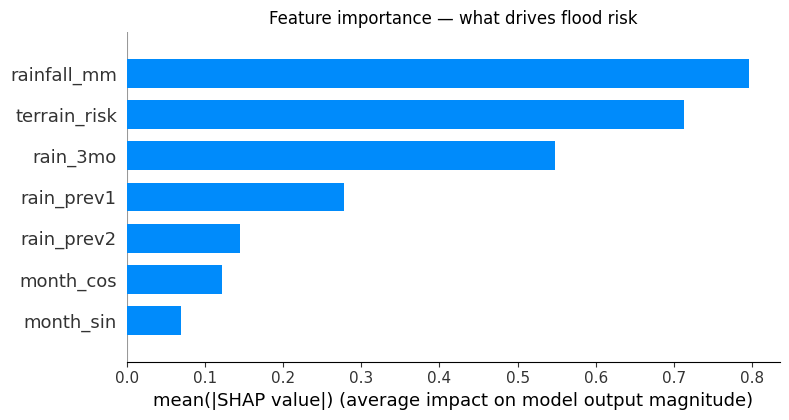

SHAP plot saved


AttributeError: You are calling a geospatial method on the GeoDataFrame, but the active geometry column ('geometry') is not present. 
There are columns with geometry data type (['GEOMETRY']), and you can either set one as the active geometry with df.set_geometry("name") or access the column as a GeoSeries (df["name"]) and call the method directly on it.

In [21]:
!pip install shap folium -q
import shap, folium, joblib
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np

model = joblib.load("/content/drive/MyDrive/srilanka_flood/models/xgb_model.pkl")

FEATURES = ['rainfall_mm','rain_prev1','rain_prev2','rain_3mo',
            'month_sin','month_cos','terrain_risk']

# ── SHAP feature importance ───────────────────────────────
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[FEATURES])

plt.figure(figsize=(9,5))
shap.summary_plot(shap_values, X_test[FEATURES],
                  plot_type="bar", show=False)
plt.title("Feature importance — what drives flood risk")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/srilanka_flood/shap_importance.png", dpi=150)
plt.show()
print("SHAP plot saved")

# ── Risk map for latest month ─────────────────────────────
# Predict risk score for every district using Dec 2020 rainfall
latest = grid[grid['year']==2020][grid['month']==12][
    ['district','rainfall_mm','rain_prev1','rain_prev2',
     'rain_3mo','month_sin','month_cos','terrain_risk']
].drop_duplicates('district')

latest['risk_score'] = model.predict_proba(
    latest[FEATURES])[:,1]

# Load Sri Lanka district shapefile
lka = gpd.read_file(
    "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_LKA_1.json"
)
lka.columns = [c.upper() for c in lka.columns]

# Merge risk scores
lka = lka.merge(latest[['district','risk_score']],
                left_on='NAME_1', right_on='district', how='left')
lka['risk_score'] = lka['risk_score'].fillna(0.2)

# ── Draw Folium choropleth map ────────────────────────────
m = folium.Map(location=[7.9, 80.7], zoom_start=7,
               tiles='CartoDB positron')

folium.Choropleth(
    geo_data=lka.__geo_interface__,
    data=lka,
    columns=['NAME_1','risk_score'],
    key_on='feature.properties.NAME_1',
    fill_color='RdYlGn_r',
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name='Flood/Landslide Risk Score',
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0]
).add_to(m)

# Add district labels
for _, row in lka.iterrows():
    if row.geometry:
        centroid = row.geometry.centroid
        folium.Tooltip(
            f"{row['NAME_1']}: {row['risk_score']:.2f}"
        ).add_to(
            folium.CircleMarker(
                location=[centroid.y, centroid.x],
                radius=4, color='black', fill=True
            ).add_to(m)
        )

map_path = "/content/drive/MyDrive/srilanka_flood/risk_map.html"
m.save(map_path)
print(f"Map saved → {map_path}")
print("\nTop 5 highest risk districts:")
print(latest.sort_values('risk_score', ascending=False)
      [['district','risk_score']].head())
m

In [22]:
# Fix geometry column name and redraw map
lka = lka.set_geometry("GEOMETRY")

m = folium.Map(location=[7.9, 80.7], zoom_start=7,
               tiles='CartoDB positron')

folium.Choropleth(
    geo_data=lka.__geo_interface__,
    data=lka,
    columns=['NAME_1','risk_score'],
    key_on='feature.properties.NAME_1',
    fill_color='RdYlGn_r',
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name='Flood/Landslide Risk Score',
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0]
).add_to(m)

# District tooltips
for _, row in lka.iterrows():
    if row.GEOMETRY:
        centroid = row.GEOMETRY.centroid
        folium.CircleMarker(
            location=[centroid.y, centroid.x],
            radius=4, color='black', fill=True,
            tooltip=f"{row['NAME_1']}: {row['risk_score']:.2f}"
        ).add_to(m)

map_path = "/content/drive/MyDrive/srilanka_flood/risk_map.html"
m.save(map_path)
print(f"Map saved → {map_path}")
print("\nTop 5 highest risk districts:")
print(latest.sort_values('risk_score', ascending=False)
      [['district','risk_score']].head())
m

Map saved → /content/drive/MyDrive/srilanka_flood/risk_map.html

Top 5 highest risk districts:
          district  risk_score
5795     Ratnapura    0.896668
2771         Kandy    0.896190
755        Badulla    0.896190
3023       Kegalle    0.823101
5039  Nuwara Eliya    0.823101


In [23]:
# ── Add stronger features to existing grid ────────────────
grid['rain_prev3']     = grid.groupby('district')['rainfall_mm'].shift(3)
grid['rain_6mo']       = grid[['rainfall_mm','rain_prev1','rain_prev2',
                                'rain_prev3']].sum(axis=1)
grid['rain_anomaly']   = grid['rainfall_mm'] - grid.groupby(
                         'month')['rainfall_mm'].transform('mean')
grid['rain_x_terrain'] = grid['rainfall_mm'] * grid['terrain_risk']
grid['is_monsoon']     = grid['month'].isin([4,5,10,11]).astype(int)

FEATURES_V2 = [
    'rainfall_mm','rain_prev1','rain_prev2','rain_prev3',
    'rain_3mo','rain_6mo','rain_anomaly',
    'rain_x_terrain','terrain_risk',
    'month_sin','month_cos','is_monsoon'
]

grid2 = grid.dropna(subset=FEATURES_V2)
train2 = grid2[grid2['year'] <= 2017]
test2  = grid2[grid2['year'] >= 2018]

X_train2, y_train2 = train2[FEATURES_V2], train2['disaster']
X_test2,  y_test2  = test2[FEATURES_V2],  test2['disaster']

import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

model_v2 = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.02,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=3, gamma=1,
    scale_pos_weight=int((y_train2==0).sum()/(y_train2==1).sum()),
    random_state=42, eval_metric='aucpr'
)
model_v2.fit(X_train2, y_train2,
             eval_set=[(X_test2, y_test2)], verbose=False)

# Optimal threshold
y_proba2 = model_v2.predict_proba(X_test2)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_test2, y_proba2)
f1_scores = 2*precisions*recalls/(precisions+recalls+1e-8)
best_thresh = thresholds[f1_scores[:-1].argmax()]

y_pred2 = (y_proba2 >= best_thresh).astype(int)

print(f"Optimal threshold: {best_thresh:.3f}")
print("\n── Model v2 results ──")
print(classification_report(y_test2, y_pred2,
      target_names=['No disaster','Disaster']))
print(f"AUC-ROC: {roc_auc_score(y_test2, y_proba2):.3f}")

import joblib
joblib.dump((model_v2, best_thresh, FEATURES_V2),
    "/content/drive/MyDrive/srilanka_flood/models/xgb_v2.pkl")
print("\nv2 model saved to Drive")

Optimal threshold: 0.447

── Model v2 results ──
              precision    recall  f1-score   support

 No disaster       0.94      0.81      0.87       772
    Disaster       0.37      0.70      0.49       128

    accuracy                           0.79       900
   macro avg       0.66      0.75      0.68       900
weighted avg       0.86      0.79      0.81       900

AUC-ROC: 0.822

v2 model saved to Drive
